 **Problem Statement:**

Imagine you are a crciket coach of Indian Cricekt Team and you have stats of 100 Players. You want to group players with similar abilities so that you can select players for different match staretigies.

Our goal is to group players with similar performance characteristics into clusters.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
#if we proceed this as usual we can face an encoding problem
#Panda is trying to read a file that is stored in utf-8 type file by default but here it is stored in latin
#But this file is not saved in this utf-8 type then we use latin1 because its stored in latin datatype
#differnt types are utf-8,cp1252,latin1,ISO-8859-1

In [ ]:
#Loading the dataset
dataset=pd.read_csv("/content/Cricket.csv", encoding='latin1')
dataset.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


## Notebook Summary and Current Progress

**Problem Statement:** The goal is to group Indian Cricket Team players with similar performance characteristics into clusters to aid in team selection for different match strategies, based on their stats.

**Current Status:**
*   The dataset `Cricket.csv` has been successfully loaded into a pandas DataFrame named `dataset`.
*   The initial rows have been displayed, confirming the data structure and content. We handled a `UnicodeDecodeError` by specifying `encoding='latin1'` and corrected `dataset.head` to `dataset.head()` for proper display.

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [ ]:
# Now here Span column is in string format  that model can't actual interpret
#So we need to convert it into experience column without string
#so we can simply make experience coulmn from it where we will have starting year and end year by splitting the span column

In [ ]:
dataset[['start','end']]=dataset['Span'].str.split('-',expand=True)

In [ ]:
dataset

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1975,1991
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,2002,2015
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,2001,2011
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
 13  start   79 non-null     object 
 14  end     79 non-null     object 
dtypes: float64(2), int64(8), object(5)
memory usage: 9.4+ KB


In [ ]:
dataset.describe()

,Mat,Inns,NO,Runs,Ave,BF,SR,100,50,0
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,245.075949,230.544304,30.037975,7618.139241,38.523291,9684.455696,79.295316,11.556962,46.443038,13.253165
std,74.211716,70.321022,14.421710,2551.873313,5.919093,3193.835825,9.925307,8.092014,16.351701,5.925755
min,128.000000,127.000000,4.000000,5080.000000,23.570000,5504.000000,60.570000,0.000000,23.000000,3.000000
25%,188.000000,177.000000,17.500000,5759.000000,34.600000,7393.500000,73.725000,6.000000,34.500000,9.000000
50%,232.000000,217.000000,29.000000,6798.000000,37.870000,9134.000000,77.730000,10.000000,42.000000,13.000000
75%,281.500000,261.500000,40.000000,8739.500000,41.845000,10976.000000,85.180000,15.500000,54.000000,16.000000
max,463.000000,452.000000,70.000000,18426.000000,53.940000,21367.000000,117.000000,49.000000,96.000000,34.000000


In [ ]:
#Converting the datatype of start and end into integer
dataset['start']=dataset['start'].astype(int)
dataset['end']=dataset['end'].astype(int)

In [ ]:
dataset['Experience']=dataset['end']-dataset['start']

In [ ]:
dataset

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,Experience
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


In [ ]:
dataset.drop(columns=['Span','start','end'],axis=1,inplace=True)

In [ ]:
dataset

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,SR Tendulkar (INDIA),463,452,41,18426,200*,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,133*,45.03,7908,64.92,11,31,3,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,96*,43.40,6945,73.75,0,42,6,13
76,PD Collingwood (ENG),197,181,37,5092,120*,35.36,6614,76.98,5,26,7,10
77,A Symonds (AUS),198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


Now in HS we can see that we have various score having'*' which basically means that they are object datatypes inspite of having other values whuch are numeric

In [ ]:
dataset

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,SR Tendulkar (INDIA),463,452,41,18426,NaN,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169.0,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164.0,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189.0,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144.0,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,NaN,45.03,7908,64.92,11,31,3,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,NaN,43.40,6945,73.75,0,42,6,13
76,PD Collingwood (ENG),197,181,37,5092,NaN,35.36,6614,76.98,5,26,7,10
77,A Symonds (AUS),198,161,33,5088,156.0,39.75,5504,92.44,6,30,15,11


### Correcting 'HS' Column Cleaning

Since the previous attempt to clean the 'HS' column converted it to numeric with `NaN` values, we need to reload the dataset to get the original string values back. Then, we will apply `str.replace` to remove the '*' character and convert the column to a numeric type.

In [ ]:
# Reload the dataset to get the original 'HS' column back in string format
dataset = pd.read_csv("/content/Cricket.csv", encoding='latin1')

# Re-apply Span column processing
dataset[['start','end']] = dataset['Span'].str.split('-', expand=True)
dataset['start'] = dataset['start'].astype(int)
dataset['end'] = dataset['end'].astype(int)
dataset['Experience'] = dataset['end'] - dataset['start']
dataset.drop(columns=['Span','start','end'], axis=1, inplace=True)

# Clean 'HS' column using str.replace and then convert to numeric
dataset['HS'] = dataset['HS'].str.replace('*', '', regex=False)
dataset['HS'] = pd.to_numeric(dataset['HS'], errors='coerce').astype(int)

print("Dataset after reloading, re-processing 'Span', and cleaning 'HS':")
display(dataset.head())

Dataset after reloading, re-processing 'Span', and cleaning 'HS':


,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17


In [ ]:
# Display info to confirm data types
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      79 non-null     object 
 1   Mat         79 non-null     int64  
 2   Inns        79 non-null     int64  
 3   NO          79 non-null     int64  
 4   Runs        79 non-null     int64  
 5   HS          79 non-null     int64  
 6   Ave         79 non-null     float64
 7   BF          79 non-null     int64  
 8   SR          79 non-null     float64
 9   100         79 non-null     int64  
 10  50          79 non-null     int64  
 11  0           79 non-null     int64  
 12  Experience  79 non-null     int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 8.2+ KB


In [ ]:
dataset['HS']=dataset['HS'].astype(int)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [ ]:
dataset.isnull().sum()

,0
Player,0
Mat,0
Inns,0
NO,0
Runs,0
HS,0
Ave,0
BF,0
SR,0
100,0


In [ ]:
dataset.duplicated().sum()

np.int64(0)

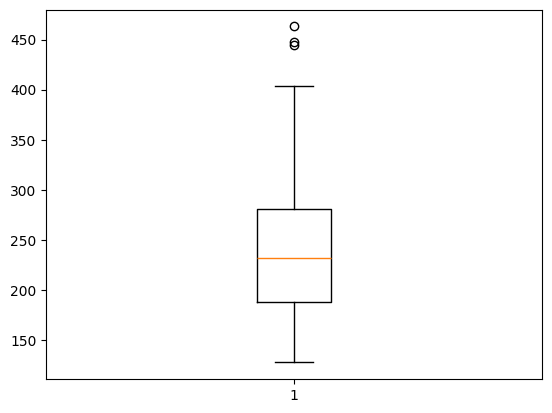

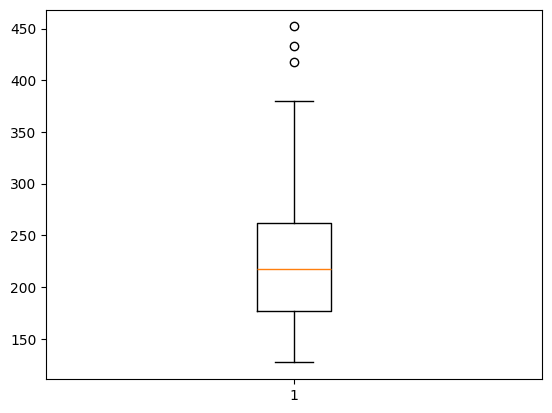

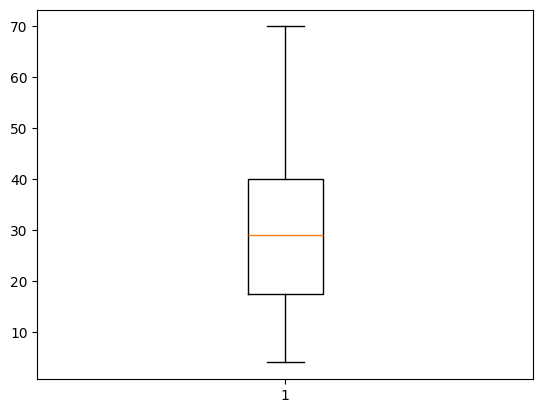

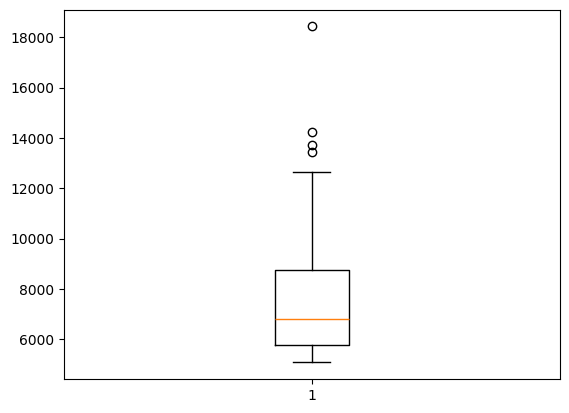

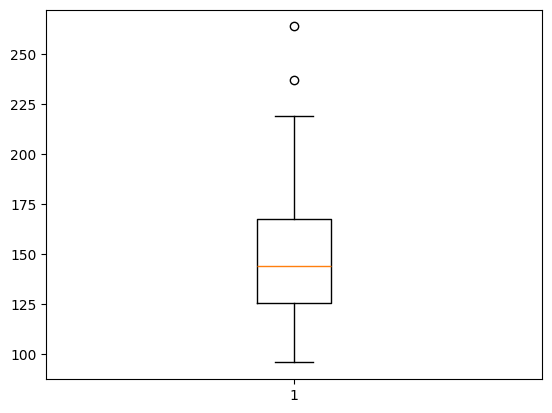

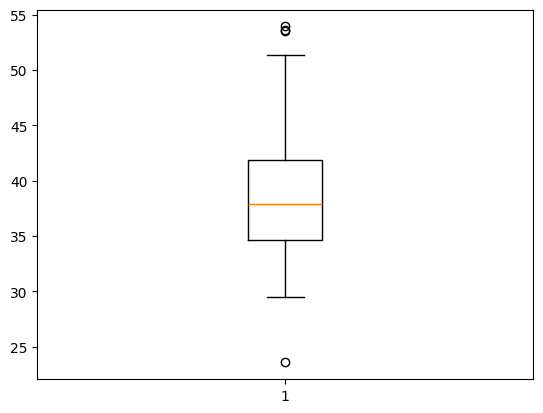

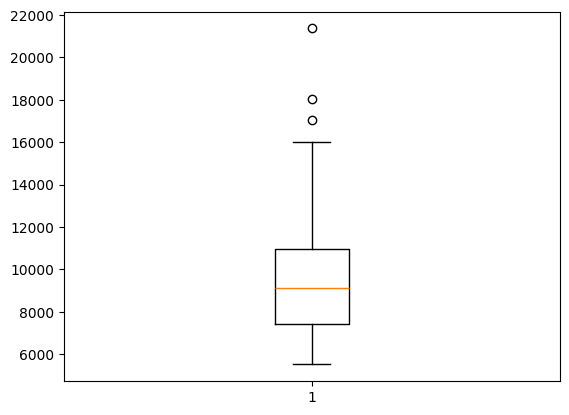

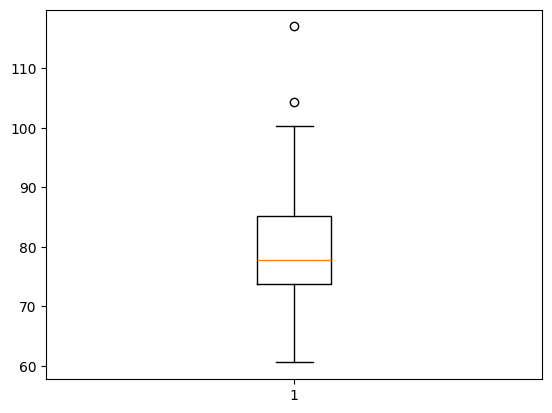

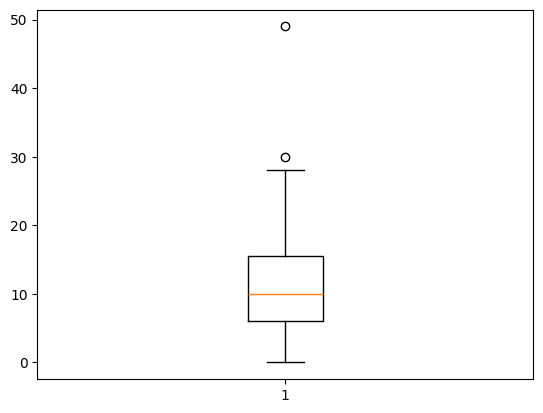

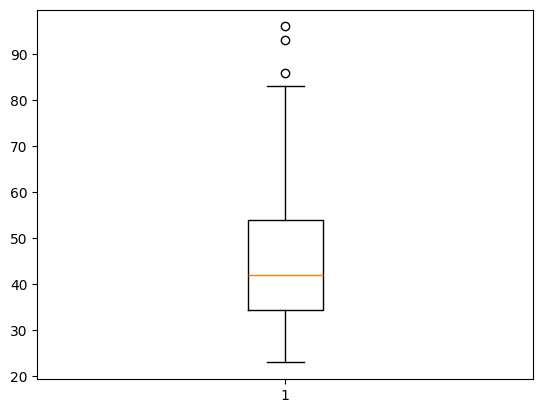

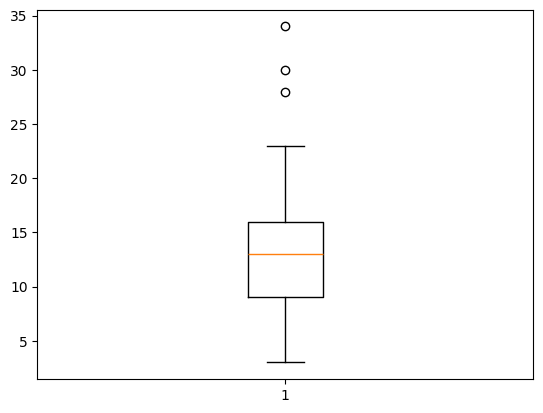

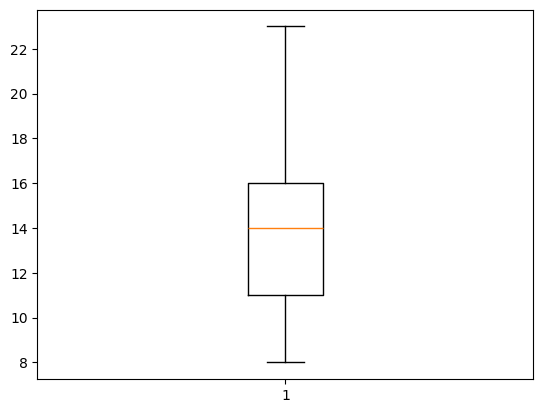

In [ ]:
for column in dataset:
  if(dataset[column].dtype==np.int64 or dataset[column].dtype==np.float64):
    plt.boxplot(dataset[column])
    plt.show()

Now if we think logically we dont need PLayers name do not contrubute to performnave and hence we will remove them but after clusterung we neeed to remove them to get clusterd groups for each player. so we need to copy data

WE will create a copy of whole data

In [ ]:
dataset_copy=dataset.copy()

In [ ]:
dataset_copy

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15


In [ ]:
dataset_copy.drop(columns=['Player'],axis=1,inplace=True)

KeyError: "['Player'] not found in axis"

In [ ]:
dataset_copy

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...
74,128,127,13,5134,133,45.03,7908,64.92,11,31,3,16
75,162,149,31,5122,96,43.40,6945,73.75,0,42,6,13
76,197,181,37,5092,120,35.36,6614,76.98,5,26,7,10
77,198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


**Standardzation**
Standardization is a technique which is used to sacle the numerical data.

We can see every column has its own range and k means work on euclidiean distances. Higher range columb will dominate that feature causing biasness.This is omething we dont want that is why we want all of this in similar range and thats why we want standardisation

Z=(x-m)/standard deviation
and m=mean of independent features

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
# Clean 'HS' column in dataset_copy
# Check if 'HS' column exists and is of object type
if 'HS' in dataset_copy.columns and dataset_copy['HS'].dtype == 'object':
    dataset_copy['HS'] = dataset_copy['HS'].astype(str).str.replace('*', '', regex=False)
    dataset_copy['HS'] = pd.to_numeric(dataset_copy['HS'], errors='coerce').astype(int)

# Re-process Span for dataset_copy if 'Span' exists and 'start'/'end' don't
# This ensures 'Experience' is calculated on dataset_copy if it wasn't already.
if 'Span' in dataset_copy.columns and 'start' not in dataset_copy.columns:
    dataset_copy[['start','end']] = dataset_copy['Span'].astype(str).str.split('-', expand=True)
    dataset_copy['start'] = dataset_copy['start'].astype(int)
    dataset_copy['end'] = dataset_copy['end'].astype(int)
    dataset_copy['Experience'] = dataset_copy['end'] - dataset_copy['start']

# Drop non-numeric columns and derived temporary columns from dataset_copy
columns_to_drop_from_copy = []
if 'Span' in dataset_copy.columns:
    columns_to_drop_from_copy.append('Span')
if 'start' in dataset_copy.columns:
    columns_to_drop_from_copy.append('start')
if 'end' in dataset_copy.columns:
    columns_to_drop_from_copy.append('end')
if 'Player' in dataset_copy.columns:
    columns_to_drop_from_copy.append('Player')

if columns_to_drop_from_copy:
    dataset_copy.drop(columns=columns_to_drop_from_copy, axis=1, inplace=True, errors='ignore')

# Now, apply the scaler to the cleaned and prepared numerical dataset_copy
dataset_scaled = scaler.fit_transform(dataset_copy)

In [ ]:
dataset_scaled

array([[ 2.95528204e+00,  3.16933340e+00,  7.64962749e-01,
         4.26232808e+00,  1.63244320e+00,  1.07229395e+00,
         3.68121424e+00,  7.03151526e-01,  4.65672622e+00,
         3.05005720e+00,  1.14583653e+00],
       [ 2.15517925e+00,  2.13891509e+00,  7.64962749e-01,
         2.60911662e+00,  6.35223595e-01,  5.87724608e-01,
         2.63538469e+00, -4.41394951e-02,  1.67188751e+00,
         2.86541772e+00,  2.96670622e-01],
       [ 1.76190839e+00,  1.92424461e+00,  6.25396797e-01,
         2.40009894e+00,  4.74381724e-01,  5.96225824e-01,
         2.31965067e+00,  1.10996904e-01,  2.29372891e+00,
         2.18840630e+00,  1.14583653e+00],
       [ 2.71118288e+00,  2.89741746e+00, -8.40045698e-01,
         2.29204075e+00,  1.27859108e+00, -1.04790945e+00,
         1.58829472e+00,  1.20709133e+00,  2.04499235e+00,
         1.32675540e+00,  3.52350108e+00],
       [ 2.75186607e+00,  2.68274698e+00,  6.25396797e-01,
         1.98442984e+00, -1.68985764e-01, -8.76184872e-01,
  

In [ ]:
dataset_scaled = pd.DataFrame(dataset_scaled, columns=dataset_copy.columns, index=dataset_copy.index)

In [ ]:
dataset_scaled

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502
...,...,...,...,...,...,...,...,...,...,...,...
74,-1.587674,-1.481860,-1.188961,-0.979677,-0.522838,1.106299,-0.559768,-1.457604,-0.069268,-0.950465,-1.741328
75,-1.126598,-1.167010,0.067133,-0.984410,-1.713068,0.829159,-0.863213,-0.562275,-1.437319,-0.273453,-1.231828
76,-0.651961,-0.709047,0.485831,-0.996241,-0.941027,-0.537836,-0.967512,-0.234765,-0.815478,-1.258197,-1.061995
77,-0.638400,-0.995274,0.206699,-0.997819,0.217035,0.208570,-1.317278,1.332823,-0.691110,-1.012011,0.296671


MODEL BUILDING

In [ ]:
from sklearn.cluster import KMeans

Now to choose how many clusters we want it really depends on a theory and that theory os as follows


If you have like small dataset ranging from 1k to 2k rows then you can have clusters form 1 to 10

if you have a large dataset for lie 10k to 20k row values you can try k or clustrs values around 30 or n/10 where n is the number of rows.

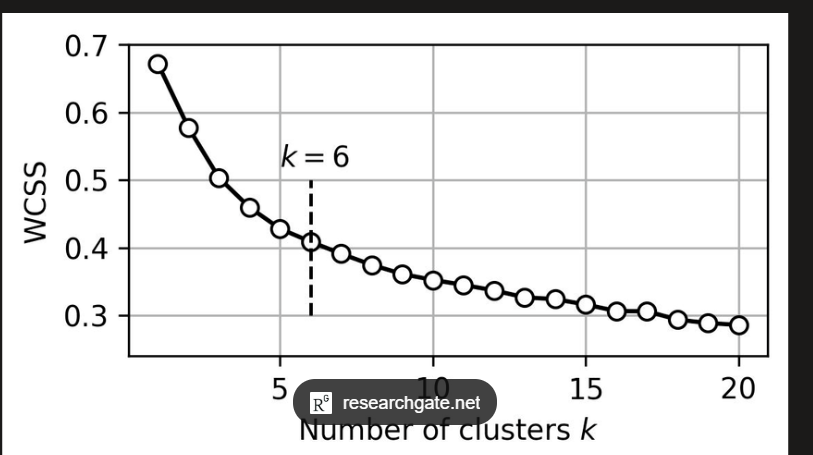

Now one thing we neeed to know :
**The Elbow Method**:
This method is used to find the optimal number of clusters (k) in K-Means by analyzing how the clustering performance changes with different k values.

Plots **WCSS (Within-Cluster Sum of Squares)** against different k values
WCSS decreases as k increases, showing better fit
The “elbow point” indicates the optimal k where improvement slows down


**Before the elbow:** WCSS drops quickly -> clusters become much better.

**After the elbow:** WCSS drops slowly -> extra clusters add little value and may lead to overfitting.

In [ ]:
k_values=[2,3,4,5,6,7,8,9]

In [ ]:
wcss=[]
for i in k_values:
  km=KMeans(n_clusters=i,random_state=32)
  km.fit(dataset_scaled)
  wcss.append(km.inertia_) #km.inertia_ will give wcss value for each k value

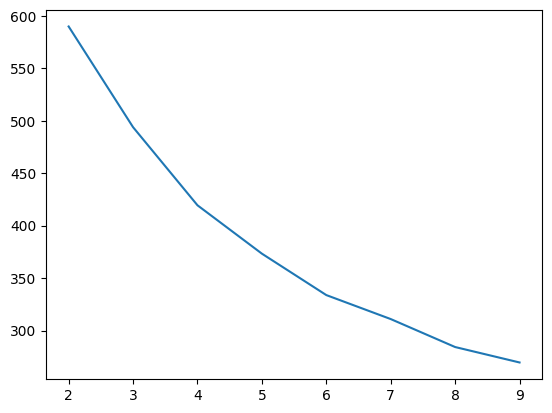

In [ ]:
plt.plot(k_values,wcss)

Now from here we are getting range of values for k_values so which k_value to choose

Thus we use **Shiloutte Score** for this problem

It tell the quality of the cluster how good a cluster is in their group!

For every k value it will give a score which is between value -1 to 1

Its like a metrics like r2_score and accuracy_score

Near +1=Excellent Clustering

Around 0=Overlapping Clusters

Near -1=Incorrect Clustering

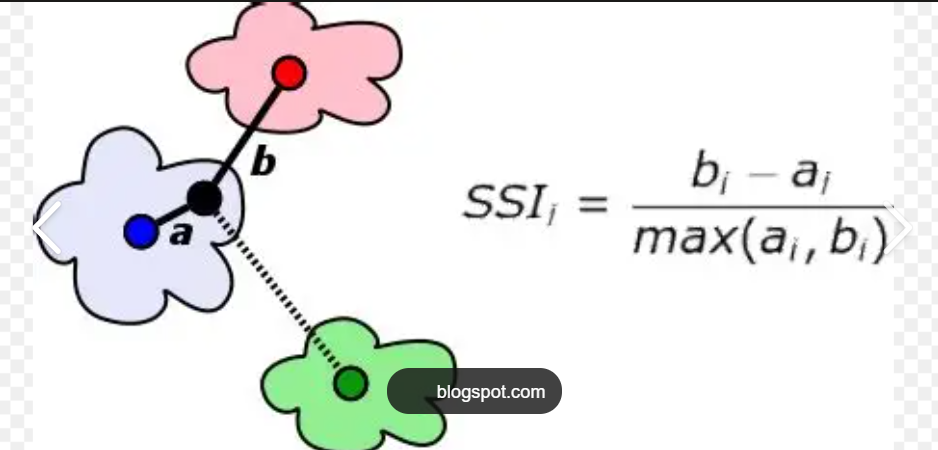

This above is the formuls for silhouette Score

Where:

a=Intra-cluster distance which is the average distance of how close a point is to other points within a cluster

b=Inter-cluster distance which is average distance to nearest other clusters

In [ ]:
k_values=range(2,10)
from sklearn.metrics import silhouette_score
score=[]

for i in k_values:
  km=KMeans(n_clusters=i,random_state=32)
  km.fit(dataset_scaled)

  silhouette_avg=silhouette_score(dataset_scaled,km.labels_)
  score.append(silhouette_avg)



Text(0, 0.5, 'Sillohuette score')

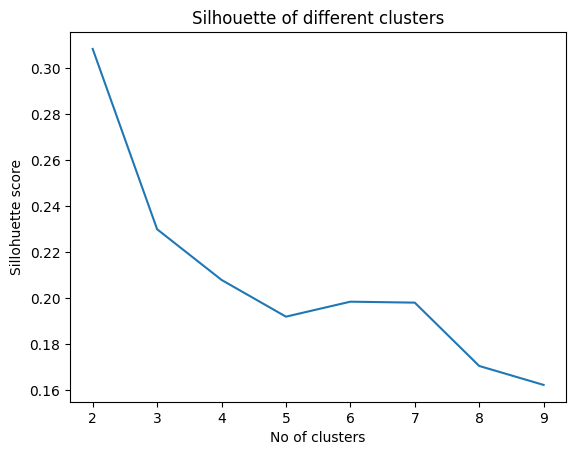

In [ ]:
plt.plot(k_values,score)
plt.title("Silhouette of different clusters")
plt.xlabel("No of clusters")
plt.ylabel("Sillohuette score")

In [ ]:
#From here max value is 3

In [ ]:
km=KMeans(n_clusters=3,random_state=42)


In [ ]:
km.fit(dataset_scaled)

KMeans(n_clusters=3, random_state=42)

In [ ]:
km.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
dataset['Cluster ID']=km.labels_

In [ ]:
dataset

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Cluster ID
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,2
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,2
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,2
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,1
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,1
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1


In [ ]:
group0=dataset[dataset['Cluster ID']==0]
group0

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Cluster ID
10,TM Dilshan (SL),1999-2016,330,303,41,10290,161*,39.27,11933,86.23,22,47,11,0
11,Mohammad Yousuf (Asia/PAK),1998-2010,288,273,40,9720,141*,41.71,12942,75.10,15,64,15,0
13,MS Dhoni (Asia/INDIA),2004-2017,295,255,70,9496,183*,51.32,10706,88.69,10,64,8,0
14,M Azharuddin (INDIA),1985-2000,334,308,54,9378,153*,36.92,12669,74.02,7,58,9,0
15,AB de Villiers (Afr/SA),2005-2017,222,213,39,9319,162*,53.55,9295,100.25,24,53,7,0
19,S Chanderpaul (WI),1994-2011,268,251,40,8778,150,41.60,12408,70.74,11,59,6,0
21,DL Haynes (WI),1978-1994,238,237,28,8648,152*,41.37,13707,63.09,17,57,13,0
22,MS Atapattu (SL),1990-2007,268,259,32,8529,132*,37.57,12594,67.72,11,59,13,0
25,V Kohli (INDIA),2008-2017,188,180,29,8146,183,53.94,8952,90.99,27,43,11,0
29,MJ Clarke (AUS),2003-2015,245,223,44,7981,130,44.58,10104,78.98,8,58,10,0


In [ ]:
group1=dataset[dataset['Cluster ID']==1]
group1

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Cluster ID
12,AC Gilchrist (AUS/ICC),1996-2008,287,279,11,9619,172,35.89,9922,96.94,16,55,19,1
16,PA de Silva (SL),1984-2003,308,296,30,9284,145,34.90,11443,81.13,11,64,17,1
17,CH Gayle (ICC/WI),1999-2015,269,264,17,9221,215,37.33,10834,85.11,22,47,23,1
18,Saeed Anwar (PAK),1989-2003,247,244,19,8824,194,39.21,10938,80.67,20,43,15,1
20,Yuvraj Singh (Asia/INDIA),2000-2017,304,278,40,8701,150,36.55,9924,87.67,14,52,18,1
23,ME Waugh (AUS),1988-2002,244,236,20,8500,173,39.35,11053,76.90,18,50,16,1
24,V Sehwag (Asia/ICC/INDIA),1999-2013,251,245,9,8273,219,35.05,7929,104.33,15,38,14,1
26,HH Gibbs (SA),1996-2010,248,240,16,8094,175,36.13,9721,83.26,21,37,22,1
27,Shahid Afridi (Asia/ICC/PAK),1996-2015,398,369,27,8064,124,23.57,6892,117.00,6,39,30,1
28,SP Fleming (ICC/NZ),1994-2007,280,269,21,8037,134*,32.40,11242,71.49,8,49,17,1


In [ ]:
group2=dataset[dataset['Cluster ID']==2]
group2

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Cluster ID
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,2
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,2
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,2
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,2
5,Inzamam-ul-Haq (Asia/PAK),1991-2007,378,350,53,11739,137*,39.52,15812,74.24,10,83,20,2
6,JH Kallis (Afr/ICC/SA),1996-2014,328,314,53,11579,139,44.36,15885,72.89,17,86,17,2
7,SC Ganguly (Asia/INDIA),1992-2007,311,300,23,11363,183,41.02,15416,73.70,22,72,16,2
8,R Dravid (Asia/ICC/INDIA),1996-2011,344,318,40,10889,153,39.16,15284,71.24,12,83,13,2
9,BC Lara (ICC/WI),1990-2007,299,289,32,10405,169,40.48,13086,79.51,19,63,16,2


<Axes: xlabel='Runs', ylabel='Ave'>

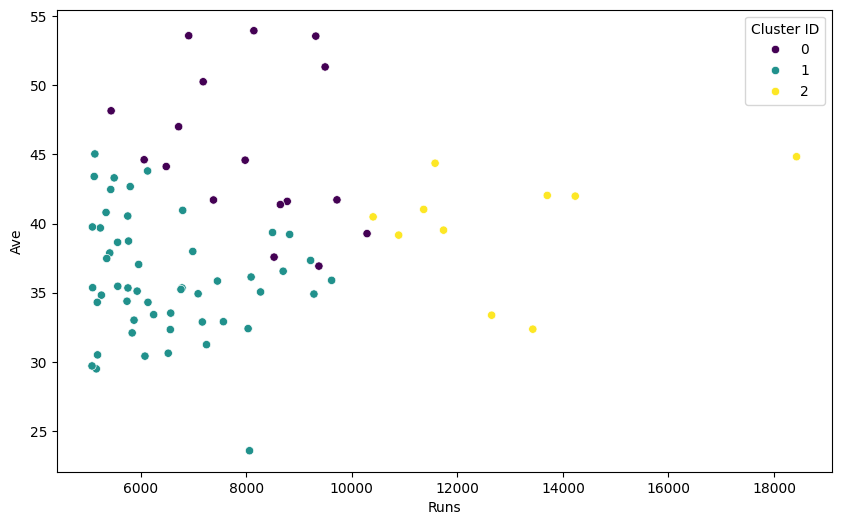

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=dataset, x='Runs', y='Ave', hue='Cluster ID', palette='viridis')

### Analyzing Cluster Characteristics

To understand what defines each cluster, we will calculate the mean of the numerical features for each group. This will highlight the average performance metrics of players within each cluster.

In [ ]:
print("\n--- Characteristics of Cluster 0 ---")
print(group0.describe().loc[['mean']])

print("\n--- Characteristics of Cluster 1 ---")
print(group1.describe().loc[['mean']])

print("\n--- Characteristics of Cluster 2 ---")
print(group2.describe().loc[['mean']])


--- Characteristics of Cluster 0 ---
             Mat        Inns         NO         Runs        Ave            BF  \
mean  236.647059  219.411765  38.647059  8028.294118  45.367059  10216.176471   

             SR        100         50         0  Cluster ID  
mean  79.881176  13.470588  50.470588  8.470588         0.0  

--- Characteristics of Cluster 1 ---
             Mat        Inns         NO         Runs        Ave           BF  \
mean  221.980769  208.923077  25.711538  6479.480769  36.019038  8244.384615   

             SR       100         50          0  Cluster ID  
mean  79.214038  8.711538  38.615385  13.538462         1.0  

--- Characteristics of Cluster 2 ---
        Mat   Inns    NO     Runs     Ave       BF      SR   100    50     0  \
mean  379.5  361.9  37.9  12841.9  39.911  16268.9  78.722  23.1  80.3  19.9   

      Cluster ID  
mean         2.0  


### Analyzing Cluster Characteristics

To understand what defines each cluster, we will calculate the mean of the numerical features for each group. This will highlight the average performance metrics of players within each cluster.

In [ ]:
print("\n--- Characteristics of Cluster 0 ---")
print(group0.describe().loc[['mean']])

print("\n--- Characteristics of Cluster 1 ---")
print(group1.describe().loc[['mean']])

print("\n--- Characteristics of Cluster 2 ---")
print(group2.describe().loc[['mean']])


--- Characteristics of Cluster 0 ---
             Mat        Inns         NO         Runs        Ave            BF  \
mean  236.647059  219.411765  38.647059  8028.294118  45.367059  10216.176471   

             SR        100         50         0  Cluster ID  
mean  79.881176  13.470588  50.470588  8.470588         0.0  

--- Characteristics of Cluster 1 ---
             Mat        Inns         NO         Runs        Ave           BF  \
mean  221.980769  208.923077  25.711538  6479.480769  36.019038  8244.384615   

             SR       100         50          0  Cluster ID  
mean  79.214038  8.711538  38.615385  13.538462         1.0  

--- Characteristics of Cluster 2 ---
        Mat   Inns    NO     Runs     Ave       BF      SR   100    50     0  \
mean  379.5  361.9  37.9  12841.9  39.911  16268.9  78.722  23.1  80.3  19.9   

      Cluster ID  
mean         2.0  


### 3D Visualization of Clusters

To further visualize the separation of player clusters, we can create a 3D scatter plot using key performance metrics like Runs, Average, and Highest Score. Each point will be colored according to its assigned cluster ID.

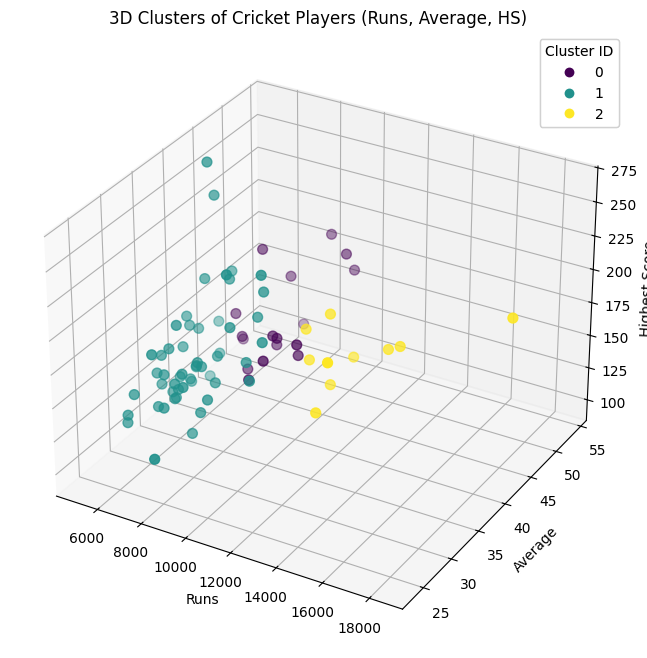

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Ensure 'HS' column is numeric before plotting
if dataset['HS'].dtype == 'object':
    dataset['HS'] = dataset['HS'].astype(str).str.replace('*', '', regex=False)
    dataset['HS'] = pd.to_numeric(dataset['HS'], errors='coerce').astype(int)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for each cluster
scatter = ax.scatter(dataset['Runs'], dataset['Ave'], dataset['HS'], c=dataset['Cluster ID'], cmap='viridis', s=50)

ax.set_xlabel('Runs')
ax.set_ylabel('Average')
ax.set_zlabel('Highest Score')
ax.set_title('3D Clusters of Cricket Players (Runs, Average, HS)')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster ID")
ax.add_artist(legend1)
plt.show()